АНАЛИТИЧЕСКИЙ МЕТОД
Цена игры: 13.8696
Стратегия A: [np.float64(0.1087), np.float64(0.6739), np.float64(0.2174)]
Стратегия B: [np.float64(0.1739), np.float64(0.6739), np.float64(0.1522)]

ЧИСЛЕННЫЙ МЕТОД БРАУНА-РОБИНСОНА
Целевая погрешность: ε = 0.1

№      A      B      Выигрыш A (x1,x2,x3)      Проигрыш B (y1,y2,y3)     v_up     v_low   
------------------------------------------------------------------------------------------
1      x1     y1     6, 17, 9                  6, 18, 5                  17.0000  5.0000  
2      x2     y3     11, 32, 28                23, 31, 20                16.0000  10.0000 
3      x2     y3     16, 47, 47                40, 44, 35                15.6667  11.6667 
4      x2     y3     21, 62, 66                57, 57, 50                16.5000  12.5000 
5      x3     y3     26, 77, 85                66, 70, 69                17.0000  13.2000 
6      x3     y1     32, 94, 94                75, 83, 88                15.6667  12.5000 
7      x2     y1     

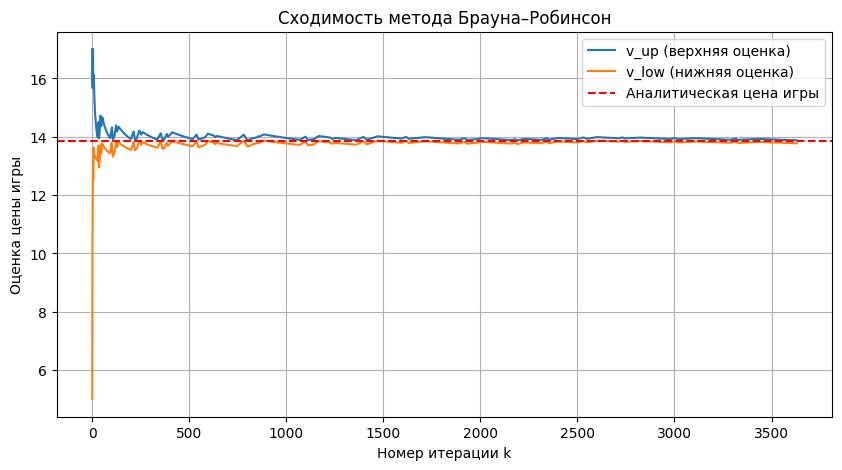

In [3]:
import numpy as np
import matplotlib.pyplot as plt

matrix = np.array([
    [6, 18, 5],
    [17, 13, 15],
    [9, 13, 19]
])

def analytical_method(C):
    # Аналитическое решение (метод обратной матрицы)
    C_inv = np.linalg.inv(C)
    total_sum = np.sum(C_inv)
    v = 1 / total_sum
    row_sums = np.sum(C_inv, axis=1)
    x = row_sums / total_sum
    col_sums = np.sum(C_inv, axis=0)
    y = col_sums / total_sum
    return v, x, y

def solve_brown_robinson(C, target_eps, max_iter=10000, max_display_rows=20):

    # Численный метод Брауна–Робинсон.

    m, n = C.shape
    acc_win_A = [0.0, 0.0, 0.0]   # накопленные выигрыши A по его стратегиям
    acc_loss_B = [0.0, 0.0, 0.0]  # накопленные проигрыши B (выигрыши A) по стратегиям B
    counts_A = [0, 0, 0]
    counts_B = [0, 0, 0]

    v_up_history = []
    v_low_history = []
    log_rows = []

    k = 1
    curr_A = 0
    curr_B = 0
    epsilon = 1.0

    # Заголовок таблицы
    header = f"{'№':<6} {'A':<6} {'B':<6} {'Выигрыш A (x1,x2,x3)':<25} {'Проигрыш B (y1,y2,y3)':<25} {'v_up':<8} {'v_low':<8}"
    log_rows.append(header)
    log_rows.append("-" * 90)

    while epsilon > target_eps and k <= max_iter:
        counts_A[curr_A] += 1
        counts_B[curr_B] += 1

        # Обновляем накопленные суммы по выигрышам
        for i in range(m):
            acc_win_A[i] += C[i][curr_B]
        for j in range(n):
            acc_loss_B[j] += C[curr_A][j]

        v_up_k = max(acc_win_A) / k
        v_low_k = min(acc_loss_B) / k

        v_up_history.append(v_up_k)
        v_low_history.append(v_low_k)

        # Погрешность = верхняя оценка - нижняя оценка (по текущим средним)
        epsilon = v_up_k - v_low_k

        win_str = f"{int(acc_win_A[0])}, {int(acc_win_A[1])}, {int(acc_win_A[2])}"
        loss_str = f"{int(acc_loss_B[0])}, {int(acc_loss_B[1])}, {int(acc_loss_B[2])}"

        row = f"{k:<6} x{curr_A+1:<5} y{curr_B+1:<5} {win_str:<25} {loss_str:<25} {v_up_k:<8.4f} {v_low_k:<8.4f}"
        log_rows.append(row)

        # Выбор следующих стратегий: A максимизирует свой накопленный выигрыш,
        # B минимизирует накопленный проигрыш
        curr_A = acc_win_A.index(max(acc_win_A))
        curr_B = acc_loss_B.index(min(acc_loss_B))

        k += 1

    steps = k - 1
    x_strat = [round(c / steps, 4) for c in counts_A]
    y_strat = [round(c / steps, 4) for c in counts_B]

    # Оценка цены игры как среднее между последними оценками
    v_res = (v_up_history[-1] + v_low_history[-1]) / 2

    # Если итераций больше max_display_rows, обрезаем вывод
    if steps > max_display_rows:
        display_log = log_rows[:max_display_rows + 1]  # +1 для заголовка
        display_log.append(f"... (всего итераций: {steps}, показаны первые {max_display_rows})")
    else:
        display_log = log_rows

    return v_res, x_strat, y_strat, v_up_history, v_low_history, steps, display_log

def main():
    print("АНАЛИТИЧЕСКИЙ МЕТОД")
    v_analytical, x_analytical, y_analytical = analytical_method(matrix)
    print(f"Цена игры: {v_analytical:.4f}")
    print(f"Стратегия A: {[round(x,4) for x in x_analytical]}")
    print(f"Стратегия B: {[round(y,4) for y in y_analytical]}")

    print("\n" + "="*70)
    print("ЧИСЛЕННЫЙ МЕТОД БРАУНА-РОБИНСОНА")
    target_eps = 0.1
    print(f"Целевая погрешность: ε = {target_eps}\n")

    v_brown, x_brown, y_brown, v_up_hist, v_low_hist, iterations, log_table = solve_brown_robinson(
        matrix, target_eps, max_display_rows=20
    )

    # Выводим таблицу
    print("\n".join(log_table))

    print(f"\nРЕЗУЛЬТАТ после {iterations} итераций:")
    print(f"Цена игры (средняя): {v_brown:.4f}")
    print(f"Стратегия A: {x_brown}")
    print(f"Стратегия B: {y_brown}")

    # Погрешность по сравнению с аналитическим решением
    print("\n" + "-"*70)
    print("СРАВНЕНИЕ С АНАЛИТИЧЕСКИМ РЕШЕНИЕМ:")
    print(f"  Аналитическая цена игры: {v_analytical:.6f}")
    print(f"  Численная оценка:        {v_brown:.6f}")
    print(f"  Абсолютная погрешность:  {abs(v_analytical - v_brown):.6f}")
    print(f"  Количество итераций:     {iterations}")

    # Построение графиков сходимости
    '''plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(v_up_hist)+1), v_up_hist, label='v_up (верхняя оценка)')
    plt.plot(range(1, len(v_low_hist)+1), v_low_hist, label='v_low (нижняя оценка)')
    plt.axhline(y=v_analytical, color='r', linestyle='--', label='Аналитическая цена игры')
    plt.xlabel('Номер итерации k')
    plt.ylabel('Оценка цены игры')
    plt.title('Сходимость метода Брауна–Робинсон')
    plt.legend()
    plt.grid(True)
    plt.show()'''

if __name__ == "__main__":
    main()